In [17]:
import jax
import jax.numpy as jnp
from orbax.checkpoint import PyTreeCheckpointer
import matplotlib.pyplot as plt
import os
import optax
import numpy as np
import matplotlib.pyplot as plt


In [8]:
print(jax.devices())

[CudaDevice(id=0)]


In [9]:
from ppo_m2 import WMTrainState, TrainState
from world_model.tokenizer import Tokenizer, EncoderDecoderConfig
from world_model.world_model import WorldModel, TransformerConfig
from models.actor_critic import ActorCriticConvRNN


In [10]:
# --- 2. Initialize dummy models and optimizers to create templates ---

# Dummy Tokenizer
tokenizer_config = EncoderDecoderConfig(
    resolution=63,
    in_channels=3,
    z_channels=128,
    ch=64,
    ch_mult=[1, 2, 4, 8],
    num_res_blocks=1,
    attn_resolutions=[],
    out_ch=3,
    dropout=0.0
)

tokenizer = Tokenizer(
    vocab_size=512, # Use the same vocab_size as in your training config
    embed_dim=128,
    encoder_config=tokenizer_config,
    decoder_config=tokenizer_config
)
dummy_obs = jnp.zeros((1, 63, 63, 3))
tokenizer_params = tokenizer.init(jax.random.PRNGKey(0), dummy_obs, train=False)['params']

# Dummy World Model (for Task 2 later)
wm_config = TransformerConfig(
            tokens_per_block=64 + 1, 
            max_blocks=16, 
            attention='block_causal',
            num_layers=3, 
            num_heads=8, 
            embed_dim=128, # The embedding dimension is 128 
            embed_pdrop=0.1, 
            resid_pdrop=0.1, 
            attn_pdrop=0.1,
        )
world_model = WorldModel(obs_vocab_size=512, act_vocab_size=17, config=wm_config)
dummy_tokens = jnp.zeros((1, 16 * (64 + 1)), dtype=jnp.int32)
wm_params = world_model.init(jax.random.PRNGKey(0), dummy_tokens, train=False)['params']

# Dummy Optimizer (must match the one used in training)
wm_tx = optax.adam(1e-3)



In [11]:
# --- 3. Now you can correctly create the empty state template ---
empty_tok_state = WMTrainState.create(
    apply_fn=tokenizer.apply,
    params=jax.tree_util.tree_map(jnp.zeros_like, tokenizer_params),
    tx=wm_tx,
    rng=jax.random.PRNGKey(0) # RNG state is part of WMTrainState
)

# You can also create the template for the world model now for later use
empty_wm_state = WMTrainState.create(
    apply_fn=world_model.apply,
    params=jax.tree_util.tree_map(jnp.zeros_like, wm_params),
    tx=wm_tx,
    rng=jax.random.PRNGKey(0)
)

print("✅ Setup complete. You can now load checkpoints.")


✅ Setup complete. You can now load checkpoints.


In [13]:
orbax_checkpointer = PyTreeCheckpointer()


In [16]:
# --- 1. Define the path to the checkpoint you want to load ---
run_id = "run-20250911_155233-26hxeu4l"
checkpoint_step = 217 # The update step you want to visualize

# Construct the relative path
relative_path = f"wandb/{run_id}/files/tokenizer_checkpoints/update_{checkpoint_step}/"

# Convert it to an absolute path
ckpt_path = os.path.abspath(relative_path)

print(f"Attempting to load tokenizer from: {ckpt_path}")

# --- 2. Restore the checkpoint ---
# This line will now work correctly
tokenizer_state = orbax_checkpointer.restore(ckpt_path, item=empty_tok_state)
tokenizer_params = tokenizer_state.params

print("✅ Tokenizer checkpoint loaded successfully!")

Attempting to load tokenizer from: /home/synaderi/Craftax_Baselines/wandb/run-20250911_155233-26hxeu4l/files/tokenizer_checkpoints/update_217
✅ Tokenizer checkpoint loaded successfully!


⚠️ Buffer loading not implemented. Using a dummy batch of random noise for now.


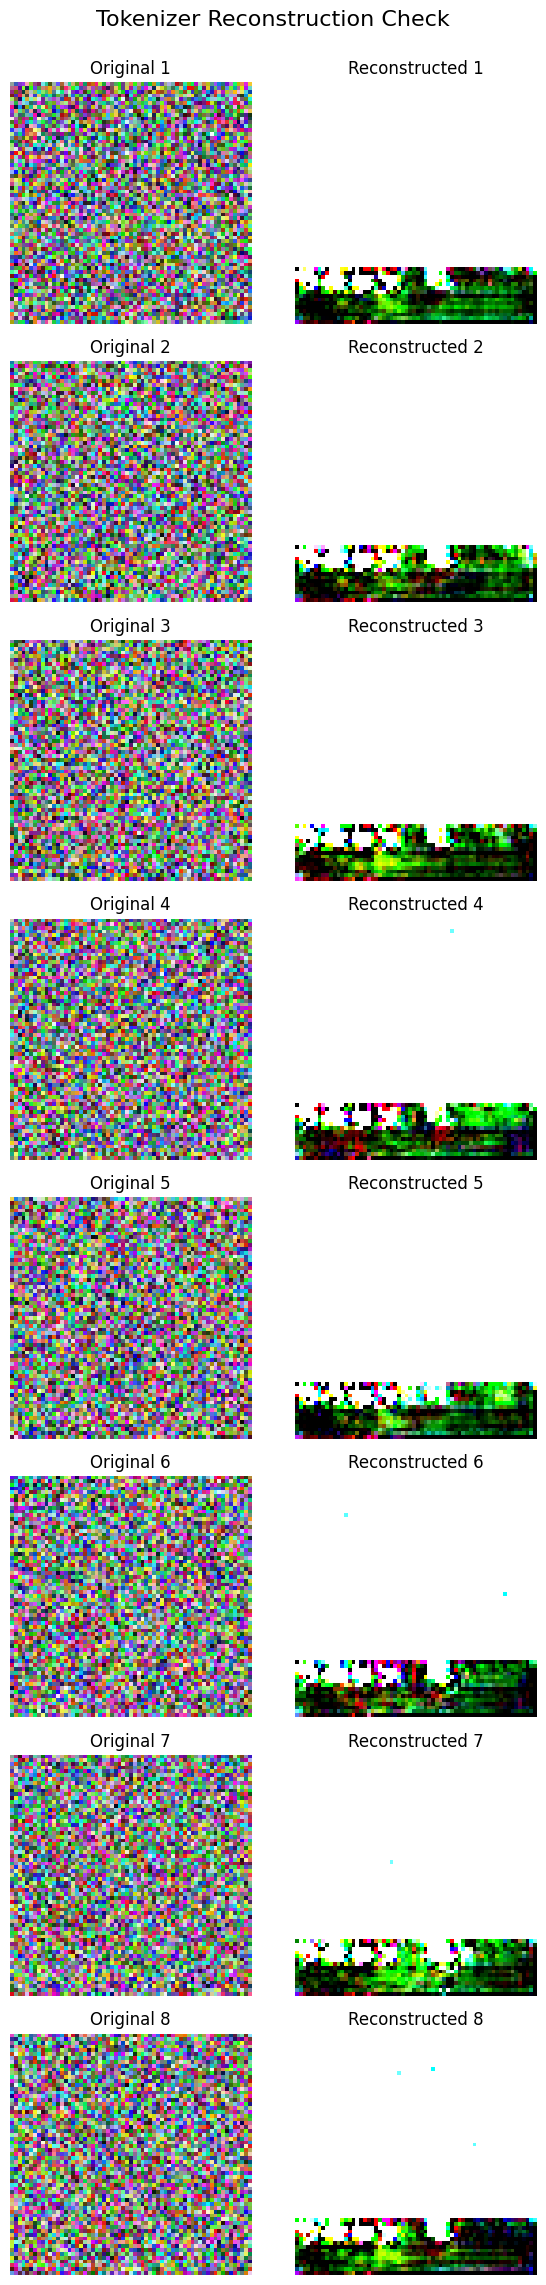

In [32]:
# --- Task 1: Visualize Tokenizer Reconstructions ---

# 1. Load sample data from your replay buffer
#    You need to implement this function to load your saved buffer
#    and sample a batch of 8 observations.
#    For now, we'll use a fallback with random noise if it's not ready.

def load_sample_obs_from_buffer(batch_size=8):
    # This is a placeholder. You should replace this with your actual
    # logic to load and sample from your saved Flashbax/Vault buffer.
    # It should return a NumPy array of shape (batch_size, 63, 63, 3).
    
    # Example placeholder:
    raise NotImplementedError("You need to implement the buffer loading logic.")

try:
    obs_batch = load_sample_obs_from_buffer(batch_size=8)
    print("✅ Sample data loaded from buffer.")
except (NameError, NotImplementedError):
    print("⚠️ Buffer loading not implemented. Using a dummy batch of random noise for now.")
    obs_batch = np.random.randint(0, 256, size=(8, 63, 63, 3), dtype=np.uint8)

# 2. Define and run the reconstruction function
@jax.jit
def reconstruct(params, obs):
    obs_float = obs.astype(jnp.float32) / 255.0
    
    # 1. Encode the image to get the full output object
    encode_output = tokenizer.apply(
        {'params': params},
        obs_float,
        method=tokenizer.encode,
        train=False
    )

    # 2. Use the quantized latent vectors from the output to decode
    # This is the crucial step that was incorrect before
    reconstructed_obs = tokenizer.apply(
        {'params': params},
        encode_output.z_quantized, # Use the quantized vectors
        method=tokenizer.decode,
        train=False # The decode method may also need this
    )
    return reconstructed_obs
    
reconstructed_batch = reconstruct(tokenizer_params, obs_batch)

# 3. Plot the results
fig, axes = plt.subplots(8, 2, figsize=(6, 24))
fig.suptitle("Tokenizer Reconstruction Check", fontsize=16)
for i in range(8):
    axes[i, 0].imshow(obs_batch[i])
    axes[i, 0].set_title(f"Original {i+1}")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(reconstructed_batch[i])
    axes[i, 1].set_title(f"Reconstructed {i+1}")
    axes[i, 1].axis("off")

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()


In [25]:
# In your main setup cell, after all the other initializations

import numpy as np
from flashbax.vault import Vault

replay_data = None
print("Attempting to load replay buffer...")
try:
    # Point to your saved buffer vault using an absolute path
    vault = Vault(
        vault_name="craftax_replay_buffer",
        rel_dir="/home/synaderi/Craftax_Baselines",
        vault_uid="chilla"
    )
    
    # Read all the data from the vault into memory
    replay_data = vault.read(vault.vault_index)
    print(f"✅ Replay buffer loaded successfully with {vault.vault_index} timesteps.")

except Exception as e:
    print(f"⚠️ Could not load replay buffer: {e}")

Attempting to load replay buffer...
Loading vault found at /home/synaderi/Craftax_Baselines/craftax_replay_buffer/chilla
✅ Replay buffer loaded successfully with 107818 timesteps.


In [29]:
# In a new cell, right after loading the buffer

if 'replay_data' in locals() and replay_data is not None:
    print("--- Inspecting the loaded replay_data ---")
    
    # Print the type of the object
    print("Type of replay_data:", type(replay_data))
    
    # Check if it has a .keys() method like a dictionary
    if hasattr(replay_data, 'keys'):
        print("Available keys:", list(replay_data.keys()))
        
    # Check if it's a named tuple with fields
    elif hasattr(replay_data, '_fields'):
        print("Available fields:", replay_data._fields)
        
    # As a last resort, print all its attributes
    else:
        print("Attributes of replay_data:", dir(replay_data))

--- Inspecting the loaded replay_data ---
Type of replay_data: <class 'flashbax.buffers.trajectory_buffer.TrajectoryBufferState'>
Available keys: ['experience', 'current_index', 'is_full']


✅ Replay buffer is already loaded.
Sampling real data for visualization...


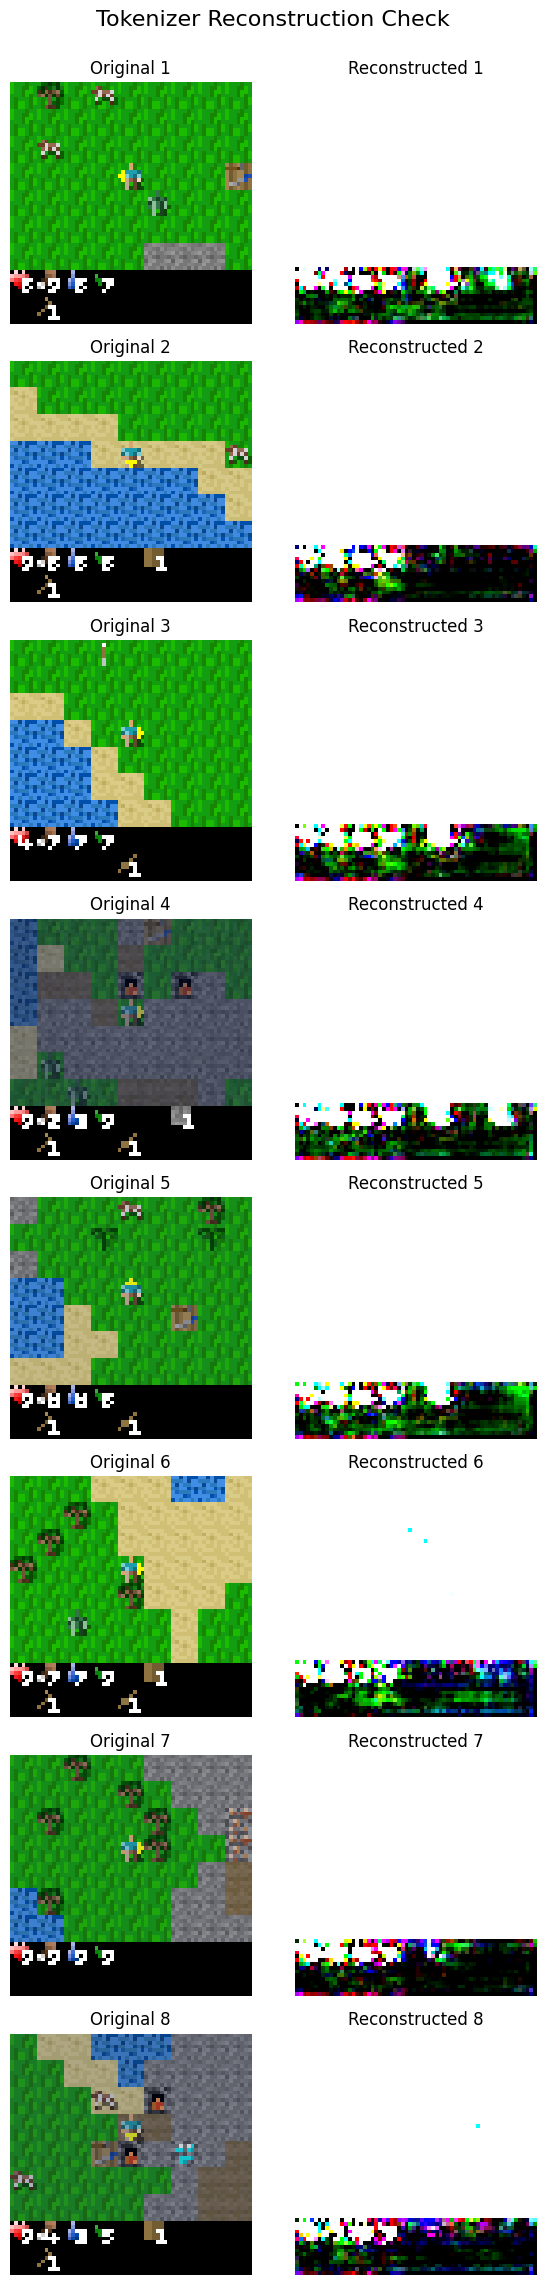

In [33]:
# In a new cell, replace your old visualization code with this

import numpy as np
import matplotlib.pyplot as plt
from flashbax.vault import Vault

# --- Part 1: Load the Replay Buffer (if not already loaded) ---
# This ensures the buffer is in memory before we try to sample from it.
if 'replay_data' not in locals() or replay_data is None:
    print("Attempting to load replay buffer...")
    try:
        vault = Vault(
            vault_name="craftax_replay_buffer",
            rel_dir="/home/synaderi/Craftax_Baselines",
            vault_uid="chilla"
        )
        replay_data = vault.read(vault.vault_index)
        print(f"✅ Replay buffer loaded successfully.")
    except Exception as e:
        print(f"⚠️ Could not load replay buffer: {e}")
        replay_data = None
else:
    print("✅ Replay buffer is already loaded.")


# --- Part 2: Define the REAL Sampling Function ---
def load_sample_obs_from_buffer(batch_size=8):
    """Samples a batch of observations from the loaded replay_data."""
    if replay_data is None:
        raise RuntimeError("Cannot sample from buffer because it failed to load.")

    # --- 💡 THE FIX IS HERE 💡 ---
    # Access the dictionary of gameplay data inside the .experience attribute
    experience_data = replay_data.experience

    # Now you can access the 'obs' array from within that dictionary
    observations_array = experience_data['obs']
    
    # The rest of the function remains the same
    num_envs = observations_array.shape[0]
    num_timesteps = observations_array.shape[1]
    
    env_indices = np.random.randint(0, num_envs, size=batch_size)
    time_indices = np.random.randint(0, num_timesteps, size=batch_size)
    
    sample_batch = observations_array[env_indices, time_indices]
    
    return sample_batch


# --- Part 3: Run the Visualization with Real Data ---
try:
    print("Sampling real data for visualization...")
    obs_batch = load_sample_obs_from_buffer(batch_size=8)

    # Define and run the reconstruction function
    @jax.jit
    def reconstruct(params, obs):
        obs_float = obs.astype(jnp.float32) / 255.0
        tokens = tokenizer.apply(
            {'params': params}, obs_float, method=tokenizer.encode, train=False
        ).tokens
        reconstructed_obs = tokenizer.apply(
            {'params': params}, tokens, method=tokenizer.decode_from_tokens
        )
        return reconstructed_obs

    reconstructed_batch = reconstruct(tokenizer_params, obs_batch)

    # Plot the results
    fig, axes = plt.subplots(8, 2, figsize=(6, 24))
    fig.suptitle("Tokenizer Reconstruction Check", fontsize=16)
    for i in range(8):
        axes[i, 0].imshow(obs_batch[i])
        axes[i, 0].set_title(f"Original {i+1}")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(reconstructed_batch[i])
        axes[i, 1].set_title(f"Reconstructed {i+1}")
        axes[i, 1].axis("off")

    plt.tight_layout(rect=[0, 0.03, 1, 0.98])
    plt.show()

except Exception as e:
    print(f"An error occurred: {e}")